## Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import platform
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
import pyEDM
from pyEDM import *
from itertools import permutations, combinations
from collections import defaultdict
import joblib
from joblib import Parallel, delayed
from tqdm import tqdm

# Display Python & OS details
print("=" * 40)
print("SYSTEM INFORMATION")
print("=" * 40)
print(f"Python Version : {sys.version.split()[0]}")
print(f"OS / Platform  : {platform.platform()}")
print(f"Architecture   : {platform.machine()}")

# Display Package Versions
print("\n" + "=" * 40)
print("PACKAGE VERSIONS")
print("=" * 40)
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"seaborn    : {sns.__version__}")
print(f"pyEDM      : {pyEDM.__version__}")
print(f"joblib     : {joblib.__version__}")
print("=" * 40)

SYSTEM INFORMATION
Python Version : 3.14.6
OS / Platform  : macOS-26.5.1-arm64-arm-64bit-Mach-O
Architecture   : arm64

PACKAGE VERSIONS
pandas     : 3.0.5
numpy      : 2.5.2
seaborn    : 0.13.2
pyEDM      : 2.5.7
joblib     : 1.5.3


## Load Data

For gap filling, you could probably use time series from different conservation units or different salmon species. Here I just used time series for species = "Chum", but it is possible there's some interaction between different species that would contain information.

In [2]:
data_raw = pd.read_csv('dataset2_spawner_surveys.csv')

# Filter for species == 'Chum' and 7 Conservation Units
cus = ['Bute Inlet', 'Georgia Strait', 'Howe Sound-Burrard Inlet', 'Loughborough', 'Northeast Vancouver Island', 
       'Southern Coastal Streams', 'Upper Knight']
data_raw = data_raw[(data_raw.species_name=='Chum') & (data_raw.cu_name_pse.isin(cus))]

# Replace negative values with NaN
data_raw.loc[data_raw['stream_observed_count'] < 0, 'stream_observed_count'] = np.nan

In [3]:
# Create a dictionary containing the time series for each stream
stream_dict = {str(stream_id): group for stream_id, group in data_raw.groupby('streamid')}

# Define the full range of years you want to cover
all_years = np.arange(data_raw['year'].min(), data_raw['year'].max() + 1)

# Process each time series
for key in list(stream_dict.keys()):

    df_stream = stream_dict[key]
    
    # Sort and keep relevant columns
    df_stream = df_stream[['year', 'stream_observed_count']].sort_values(by='year')

    # Handle duplicates
    df_stream = df_stream.groupby('year').mean().reset_index()

    # Square-root, then min-max normalize
    df_stream['stream_observed_count'] = np.sqrt(df_stream['stream_observed_count'])

    # Reindex to include all years
    df_stream = df_stream.set_index('year').reindex(all_years).reset_index()

    # Min-max normalize 
    obs = df_stream['stream_observed_count']
    if obs.notna().any():
        df_stream['stream_observed_count'] = (obs - obs.min()) / (obs.max() - obs.min())
    
    # Update the dictionary
    stream_dict[key] = df_stream

# make a look up table NEW
cu_stream = (data_raw[['cuid', 'cu_name_pse', 'streamid', 'stream_name_pse']].drop_duplicates().reset_index(drop=True))
cu_stream['streamid'] = cu_stream['streamid'].astype(str)

def get_stream_name(streamid):
    return f"{cu_stream[cu_stream['streamid'] == streamid]['stream_name_pse'].values[0]} ({streamid})"

In [4]:
# Create wide_df
series_list = []
for key, df_stream in stream_dict.items():
    s = pd.Series(data=df_stream['stream_observed_count'].values, index=df_stream['year'], name=key)
    series_list.append(s)
wide_df = pd.concat(series_list, axis=1)

# Filter data to time series with >30 non-NaN values
min_data_points = 30
valid_cols = wide_df.columns[wide_df.count() > min_data_points]

# This will be the input data
data = wide_df[valid_cols].copy().reset_index()
data = data.rename(columns={'year': 'Time'})

# print("Input data:")
# display(data)

## End-to-End Gap Filling (basic usage)

Default Behavior:
- Find columns that will cross-map well to the target.
- Constructs embeddings using the causal partners of size D.
- Cross-maps to the target and takes the ensemble average using the top k models.

Uses Simplex.

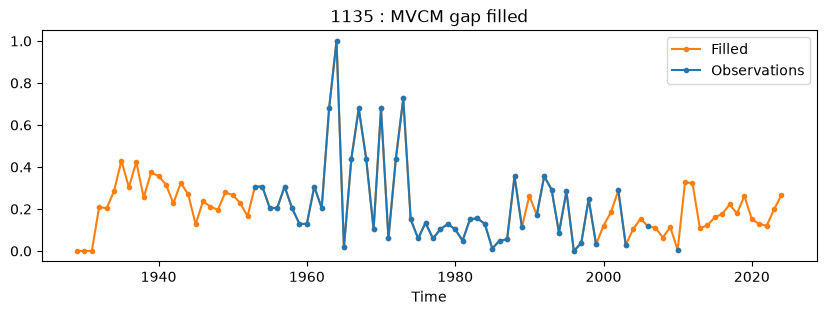

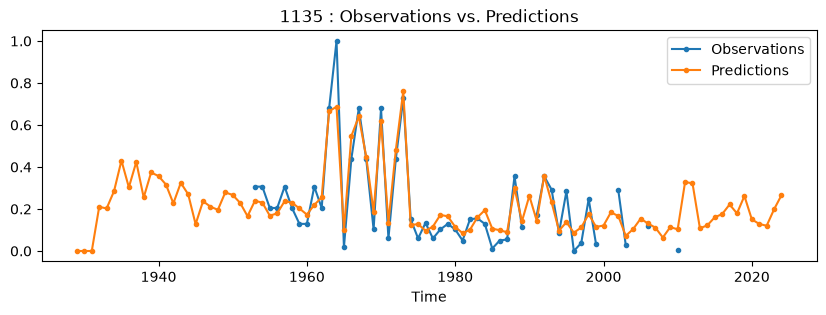

In [5]:
from pyEDM.MVCM import MVCM

target = '1135'
columns = [col for col in data.columns[1:] if col != target]
lib  = f'1 {len(data)}'
pred = f'1 {len(data)}'

mvcm = MVCM(   dataFrame     = data,             # Pandas DataFrame. First column is 'Time' (evenly spaced integers
               columns       = columns,          # List of columns to screen against the target
               target        = target,           # Target time series for gap filling
               lib           = lib,              # String of library indices, e.g. '1 100'
               pred          = pred,             # String of prediciton indices, e.g. '1 100'
               numLags       = 2,                # Number of lags in each direction
               lagTau        = -1,               # Spacing of the lags
               D             = 2,                # Dimension of multivariate embeddings
               k             = 10,               # Number of models in the ensemble
               showPlot      = True              # Show plot of filled time series
                           )
mvcm = mvcm.Run()

MVCM: Validate()
MVCM: Run()
MVCM: No pre-computed partners found. Running CrossMapScreener...
MVCM: GenerateEmbeddings()
MVCM: CrossMap()
MVCM: FillGaps()


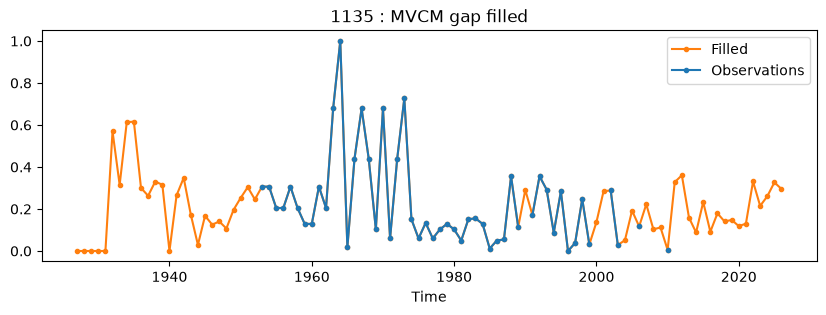

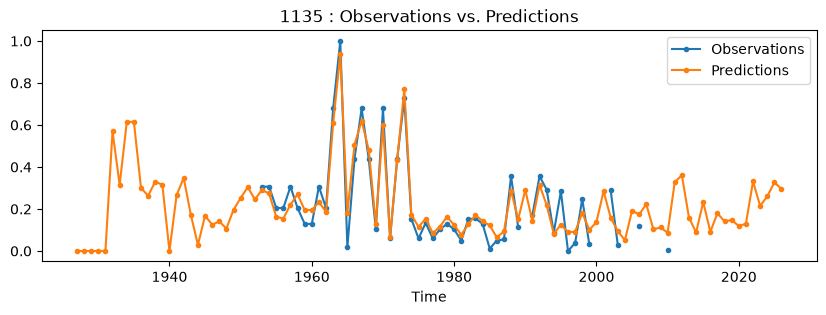

In [26]:
# More options

mvcm = MVCM(   dataFrame     = data,             # Pandas DataFrame. First column is 'Time' (evenly spaced integers
               columns       = columns,          # List of columns to screen against the target
               target        = target,           # Target time series for gap filling
               lib           = lib,              # String of library indices, e.g. '1 100'
               pred          = pred,             # String of prediciton indices, e.g. '1 100'
               numLags       = 2,                # Number of lags in each direction
               lagTau        = -1,               # Spacing of the lags
               D             = 2,                # Dimension of multivariate embeddings
               k             = 10,               # Number of models in the ensemble
               method        = 'SMap',           # Cross-mapping algorithm. 'Simplex' (default) or 'SMap'.
               theta         = 5,                # Locality parameter; required when method == 'SMap'.
               
               # Cross-map filters
               metric        = 'pearsonr',       # 'pearsonr' or 'spearmanr'.
               minN          = 10,               # Filter for minimum number of points predicted
               metricCutoff  = 0.0,              # Filter results for those with metric > metricCutoff
               testSig       = True,             # Test each result for significance
               alpha         = 0.05,             # Significance threshold
               nPartners     = len(columns),     # Only keep the top n partners

               # Additional parameters
               useTargetLags = True,             # Include lags of the target variable as potential features
               expandTime    = True,             # Reconstruct points outside the original data range
               verbose       = True,             # Print number of available features at each gap
               numProcess    = 10,               # Multiprocessing argument
               returnObject  = True,             # Return self
               showPlot      = True              # Show plot of available time series to fill each gap
                           )
mvcm = mvcm.Run()

## Modular Execution

CrossMapScreener can be run separately before MVCM in order to choose parameters like numLags and lagTau.

CrossMapScreener Validate():
CrossMapScreener: MakeBlock()


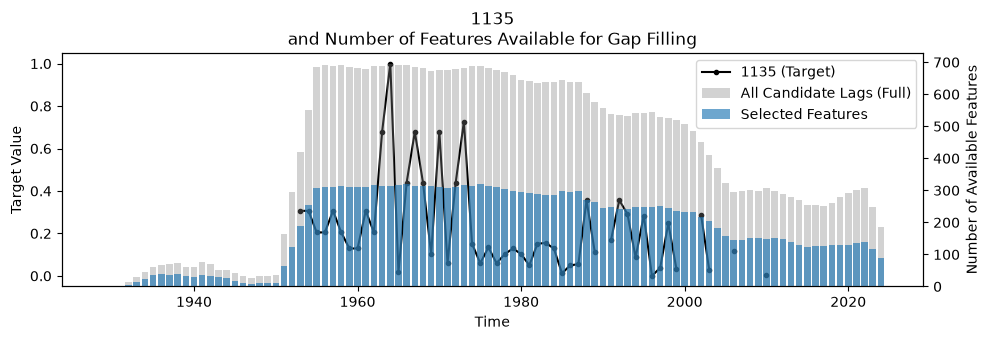

Feature availability at missing target rows:


,All Available Features,Selected Features
Time,,
1929,0,0
1930,0,0
1931,0,0
1932,13,4
1933,29,14
1934,45,24
1935,62,35
1936,66,39
1937,71,37


In [35]:
from pyEDM.MVCM import CrossMapScreener

screener = CrossMapScreener(   dataFrame     = data,             # Pandas DataFrame. First column is 'Time' (evenly spaced integers).
                               columns       = columns,          # List of columns to screen against the target
                               target        = target,           # Target time series for gap filling
                               lib           = lib,              # String of library indices, e.g. '1 100'
                               pred          = pred,             # String of prediciton indices, e.g. '1 100'
                               numLags       = 2,                # Number of lags in each direction
                               lagTau        = -1,               # Spacing of the lags
                               method        = 'SMap',           # Cross-mapping algorithm. 'Simplex' (default) or 'SMap'.
                               theta         = 5,                # Locality parameter; required when method == 'SMap'.
                               
                               # Cross-map filters
                               metric        = 'pearsonr',       # 'pearsonr' or 'spearmanr'.
                               minN          = 10,               # Filter for minimum number of points predicted
                               metricCutoff  = 0.0,              # Filter results for those with metric > metricCutoff
                               testSig       = True,             # Test each result for significance
                               alpha         = 0.05,             # Significance threshold
                               nPartners     = len(columns),     # Only keep the top n partners

                               # Additional parameters
                               # useTargetLags   = True,           # Include lags of the target variable as potential features
                               # expandTime    = True,             # Reconstruct points outside the original data range
                               
                               verbose       = True,             # Print number of available features at each gap
                               # numProcess    = 8 ,               # Multiprocessing argument
                               returnObject  = True,             # Return self
                               showPlot      = True              # Show plot of available time series to fill each gap
                           )
partners = screener.Run()

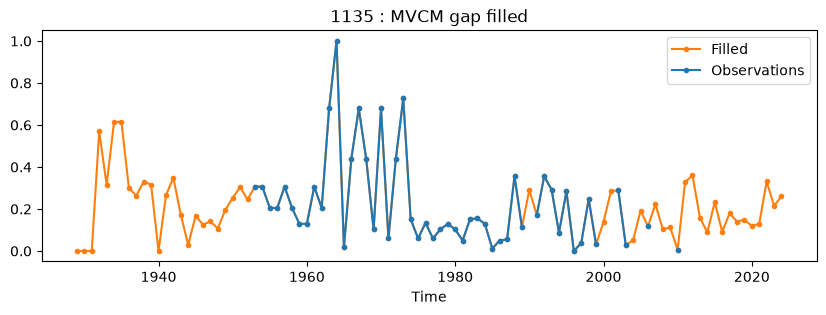

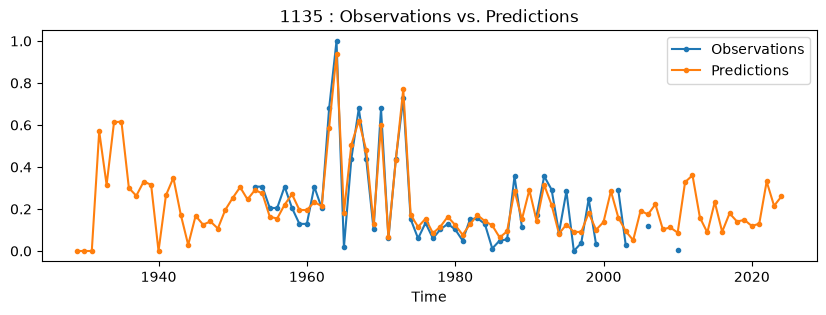

In [38]:
# Then you can pass partners into MVCM

mvcm = MVCM(   dataFrame     = data,             # Pandas DataFrame. First column is 'Time' (evenly spaced integers
               partners      = partners,         # Pre-compute causal partners
               columns       = columns,          # List of columns to screen against the target
               target        = target,           # Target time series for gap filling
               lib           = lib,              # String of library indices, e.g. '1 100'
               pred          = pred,             # String of prediciton indices, e.g. '1 100'
               numLags       = 2,                # Number of lags in each direction
               lagTau        = -1,               # Spacing of the lags
               D             = 2,                # Dimension of multivariate embeddings
               k             = 10,               # Number of models in the ensemble
               method        = 'SMap',           # Cross-mapping algorithm. 'Simplex' (default) or 'SMap'.
               theta         = 5,                # Locality parameter; required when method == 'SMap'.
                               
               # Cross-map filters
               metric        = 'pearsonr',       # 'pearsonr' or 'spearmanr'.
               minN          = 10,               # Filter for minimum number of points predicted
               metricCutoff  = 0.0,              # Filter results for those with metric > metricCutoff
               testSig       = True,             # Test each result for significance
               alpha         = 0.05,             # Significance threshold
               nPartners     = len(columns),     # Only keep the top n partners
               
               # Additional parameters
               useTargetLags   = True,           # Include lags of the target variable as potential features
               # expandTime    = True,             # Reconstruct points outside the original data range
               
               # verbose       = True,             # Print number of available features at each gap
               numProcess    = 10 ,               # Multiprocessing argument
               returnObject  = True,             # Return self
               showPlot      = True              # Show plot of available time series to fill each gap
                           )
mvcm = mvcm.Run()